In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import seaborn as sn
import math

In [24]:
df = pd.read_csv('/Users/z5116060/Desktop/GitProjects/hearing/ftran/data/glm_data.csv')
df.head()

,ORIGINAL_ID,AUDIOGRAM_COUNT,AGE_AGG,FAHL3_RIGHT_AGG,FAHL3_LEFT_AGG
0,667297,9,"52.0,53.1,54.4,55.5,56.7,58.5,62.1,64.1,64.9","28.0,23.0,28.0,32.0,50.0,52.0,35.0,53.0,55.0","15.0,28.0,22.0,30.0,33.0,37.0,38.0,38.0,43.0"
1,758754,9,"52.7,56.5,56.8,57.5,58.4,60.9,63.3,65.4,65.8","12.0,7.0,0.0,10.0,10.0,10.0,8.0,8.0,8.0","12.0,3.0,5.0,10.0,10.0,10.0,13.0,13.0,8.0"
2,78783,7,"41.3,43.6,46.6,47.6,48.6,49.5,51.8","12.0,13.0,23.0,22.0,23.0,28.0,42.0","33.0,30.0,40.0,30.0,42.0,48.0,60.0"
3,553324,7,"55.6,58.5,60.5,62.7,62.9,64.7,66.3","8.0,10.0,12.0,17.0,17.0,22.0,25.0","12.0,10.0,15.0,50.0,17.0,22.0,13.0"
4,381355,7,"65.6,67.8,70.0,73.1,74.5,76.5,77.8","15.0,13.0,13.0,15.0,25.0,20.0,30.0","37.0,35.0,40.0,40.0,50.0,43.0,50.0"


intercept age: 47.24997793567619
R-squared: 0.6264052507879226
Polynomial coefficients (highest to lowest): [np.float64(-0.16232209504478817), np.float64(21.08698499743243), np.float64(-633.965691994435)]


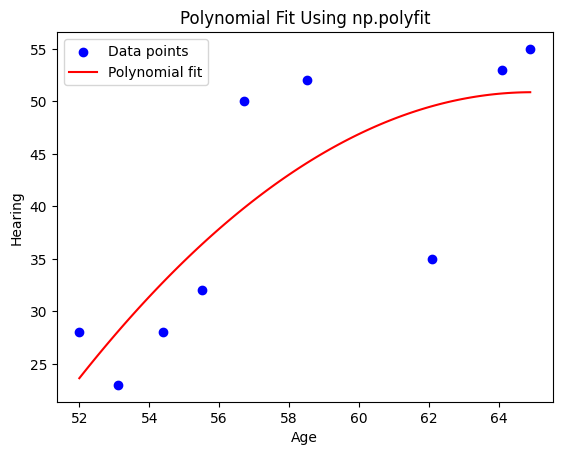

In [28]:
# first_row = df[['AGE_AGG','FAHL3_RIGHT_AGG']].iloc[0]
age_list = list(map(float, df[['AGE_AGG']].iloc[0].values[0].split(",")))
fahl3_list = list(map(float, df[['FAHL3_RIGHT_AGG']].iloc[0].values[0].split(",")))

x = np.array(age_list)
y = np.array(fahl3_list)

# Fit a quadratic (2nd-degree polynomial) using numpy
[a, b, c] = np.polyfit(x, y, 2)

coeffs = [a, b, c]


# print(f"coeffs: {coeffs}")
intercept = (-b + math.sqrt(b**2 - 4*a*c))/(2*a)
print(f"intercept age: {intercept}")


# Calculate R-squared

# Predicted y-values from the polynomial model
y_pred = np.polyval(coeffs, x)
ss_total = np.sum((y - np.mean(y)) ** 2)    # Total sum of squares
ss_residual = np.sum((y - y_pred) ** 2)     # Residual sum of squares
r_squared = 1 - (ss_residual / ss_total)

print("R-squared:", r_squared)

# Plot the original data points

x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = np.polyval(coeffs, x_fit)

print("Polynomial coefficients (highest to lowest):", coeffs)
plt.scatter(x, y, color='blue', label='Data points')

# Plot the polynomial regression line
plt.plot(x_fit, y_fit, color='red', label='Polynomial fit')

# Add labels and legend
plt.xlabel('Age')
plt.ylabel('Hearing')
plt.legend()
plt.title('Polynomial Fit Using np.polyfit')

# Show the plot
plt.show()

In [ ]:
import math

In [ ]:
-2.10869850e+01 -  math.sqrt(2.10869850e+01) -6.33965692e+02]

FAILED - Age :[44.6 46.4 47.5], Right: [8. 8. 8.], Id: 749470, Left: [32.0, 32.0, 33.0]
FAILED - Age :[70.7 72.3 73.7], Right: [22. 22. 22.], Id: 697025, Left: [20.0, 20.0, 22.0]
FAILED - Age :[59.8 65.3 71. ], Right: [15. 15. 15.], Id: 559617, Left: [18.0, 18.0, 22.0]
FAILED - Age :[61.5 61.9 62.5], Right: [22. 22. 22.], Id: 541728, Left: [48.0, 48.0, 48.0]
FAILED - Age :[72.3 75.9 77.7], Right: [32. 32. 32.], Id: 415259, Left: [27.0, 25.0, 27.0]
FAILED - Age :[67.2 70.2 73.1], Right: [22. 22. 22.], Id: 167822, Left: [20.0, 22.0, 22.0]
R-squared: [np.float64(0.5862018874407865), np.float64(0.002614529638590657), np.float64(0.8599807273908142), np.float64(0.9432290200522238), np.float64(0.6241092989567534), np.float64(0.610468693624665), np.float64(0.4572300741780888), np.float64(0.849162465441535), np.float64(0.01144067469557164), np.float64(0.4675310294193289), np.float64(0.9436218634679198), np.float64(0.9265904256054294), np.float64(0.5875183107383914), np.float64(0.880277280739651

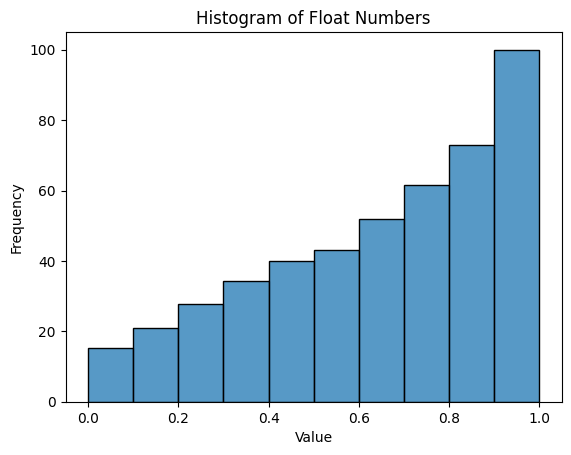

In [17]:
# first_row = df[['AGE_AGG','FAHL3_RIGHT_AGG']].iloc[0]

r_squared_list = []
slopes_list = []
intercept_list = []
r_squared_undefined_count = 0

for i in range(len(df)):
  age_list = list(map(float, df[['AGE_AGG']].iloc[i].values[0].split(",")))
  original_id = df[['ORIGINAL_ID']].iloc[i].values[0]
  fahl3_right_list = list(map(float, df[['FAHL3_RIGHT_AGG']].iloc[i].values[0].split(",")))
  fahl3_left_list = list(map(float, df[['FAHL3_LEFT_AGG']].iloc[i].values[0].split(",")))


  x = np.array(age_list)
  y = np.array(fahl3_right_list)

  # Fit a quadratic (2nd-degree polynomial) using numpy
  with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")
    coeffs = np.polyfit(x, y, 1)

    if w:
      print(f"x: {x}, y: {y}")
      for warning in w:
        print(f"Warning: {warning.message}")


  # Calculate R-squared

  # Predicted y-values from the polynomial model
  y_pred = np.polyval(coeffs, x)
  ss_total = np.sum((y - np.mean(y)) ** 2)    # Total sum of squares
  if ss_total == 0:
    r_squared_undefined_count += 1
    print(f"FAILED - Age :{x}, Right: {y}, Id: {original_id}, Left: {fahl3_left_list}")
    continue

  ss_residual = np.sum((y - y_pred) ** 2)     # Residual sum of squares

  r_squared = 1 - (ss_residual / ss_total)

  r_squared_list.append(r_squared)

print("R-squared:", r_squared_list)
print("R squared undefined count", r_squared_undefined_count)

# Create histogram
sn.histplot(r_squared_list, bins=10, edgecolor='black', stat='percent', cumulative=True)

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of Float Numbers')
plt.show()

R-squared: [np.float64(0.6264052507879226), np.float64(0.0654145641097279), np.float64(0.957354486961442), np.float64(0.9935453927378051), np.float64(0.7838614327369857), np.float64(0.6301530172033614), np.float64(0.5155344594141713), np.float64(0.9234772383251809), np.float64(0.1204221902648086), np.float64(0.4921973057445975), np.float64(0.9716472582050072), np.float64(0.9573795086660434), np.float64(0.7538426249391827), np.float64(0.9109246348320417), np.float64(0.03236993727714943), np.float64(0.759152606253745), np.float64(0.8575415625031786), np.float64(0.8390672482281227), np.float64(0.35712895280063106), np.float64(0.9873409595368214), np.float64(0.9132018656449515), np.float64(0.9690365284202686), np.float64(0.5029628417481498), np.float64(0.2273641449054722), np.float64(0.728873164618953), np.float64(0.8558053956827846), np.float64(0.9018619127188078), np.float64(0.5288199732583443), np.float64(0.38885266437353094), np.float64(0.29079084103441444), np.float64(0.93224599202212

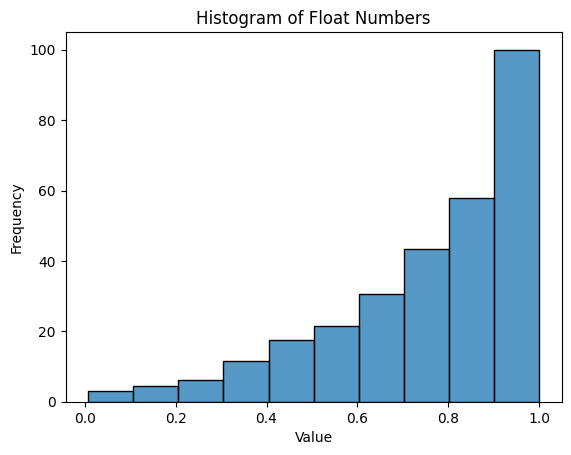

In [19]:
# first_row = df[['AGE_AGG','FAHL3_RIGHT_AGG']].iloc[0]

r_squared_list = []
slopes_list = []
intercept_list = []
r_squared_undefined_count = 0

for i in range(len(df)):
  age_list = list(map(float, df[['AGE_AGG']].iloc[i].values[0].split(",")))
  original_id = df[['ORIGINAL_ID']].iloc[i].values[0]
  fahl3_right_list = list(map(float, df[['FAHL3_RIGHT_AGG']].iloc[i].values[0].split(",")))
  fahl3_left_list = list(map(float, df[['FAHL3_LEFT_AGG']].iloc[i].values[0].split(",")))
  original_id = df[['ORIGINAL_ID']].iloc[i].values[0]
  audiogram_count = df[['AUDIOGRAM_COUNT']].iloc[i].values[0]

  if audiogram_count < 4:
    continue

  x = np.array(age_list)
  y = np.array(fahl3_right_list)

  # Fit a quadratic (2nd-degree polynomial) using numpy
  with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")
    coeffs = np.polyfit(x, y, 2)

    if w:
      print(f"x: {x}, y: {y}")
      for warning in w:
        print(f"Warning: {warning.message}")


  # Calculate R-squared

  # Predicted y-values from the polynomial model
  y_pred = np.polyval(coeffs, x)
  ss_total = np.sum((y - np.mean(y)) ** 2)    # Total sum of squares
  if ss_total == 0:
    r_squared_undefined_count += 1
    print(f"FAILED - Age :{x}, Right: {y}, Id: {original_id}, Left: {fahl3_left_list}")
    continue

  ss_residual = np.sum((y - y_pred) ** 2)     # Residual sum of squares

  r_squared = 1 - (ss_residual / ss_total)

  r_squared_list.append(r_squared)

print("R-squared:", r_squared_list)
print("R squared undefined count", r_squared_undefined_count)

# Create histogram
# plt.hist(r_squared_list, bins=10, edgecolor='black')
# Create histogram
print(f"len: {len(r_squared_list)}")
sn.histplot(r_squared_list, bins=10, edgecolor='black', stat='percent', cumulative=True)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of Float Numbers')
plt.show()